GPU : NVIDIA A100-SXM4-40GB
dtype: torch.bfloat16
Compiling & warming up...
DPO final P(preferred): 0.9961
PPO final P(preferred): 0.8953


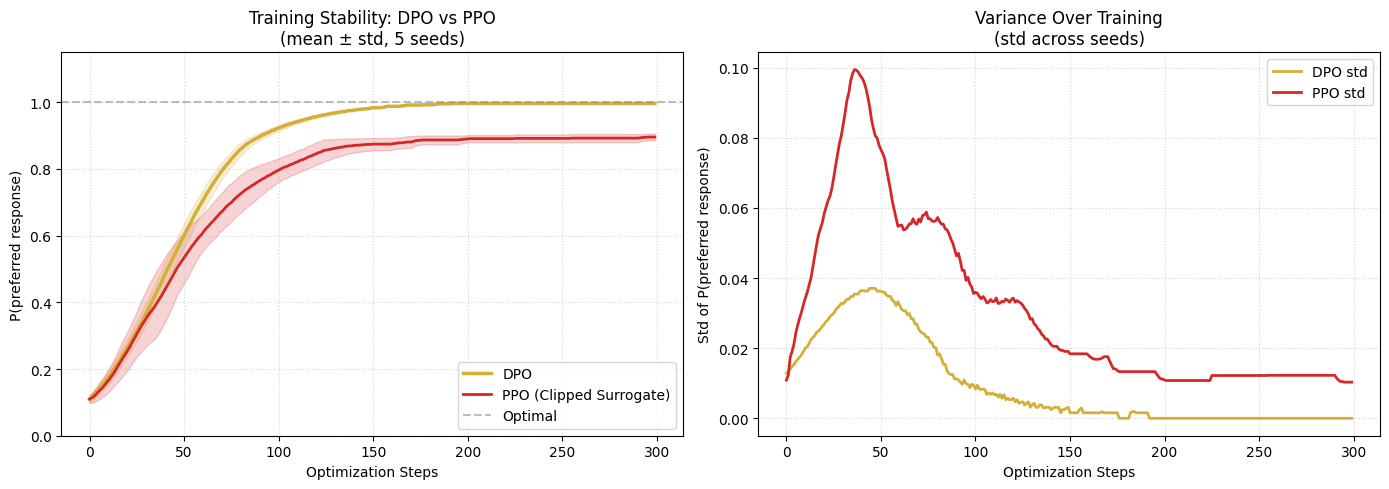

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# ═══════════════════════════════════════════════════════════════
#  A100 전역 플래그
# ═══════════════════════════════════════════════════════════════
torch.backends.cuda.matmul.allow_tf32 = True   # FP32 matmul → TF32 자동 변환
torch.backends.cudnn.allow_tf32       = True
torch.backends.cudnn.benchmark        = True
torch.set_float32_matmul_precision('high')      # PyTorch 2.0+

DEVICE     = torch.device("cuda")
DTYPE      = torch.bfloat16   # A100 BF16: FP32급 dynamic range, FP16급 처리속도

N_SEEDS    = 5
VOCAB_SIZE = 10
STEPS      = 300
BETA       = 0.1
LR         = 0.05
EPSILON    = 0.2   # PPO clip ratio
Y_W, Y_L   = 0, 1


# ═══════════════════════════════════════════════════════════════
#  배치 초기화 — S개 시드를 단일 [S, V] 텐서로
# ═══════════════════════════════════════════════════════════════
def init_weights(n_seeds: int, vocab_size: int, std: float = 0.1) -> torch.Tensor:
    """시드별 독립 초기화 후 스택 → [S, V]"""
    rows = []
    for s in range(n_seeds):
        torch.manual_seed(s)
        rows.append(torch.randn(vocab_size) * std)
    return torch.stack(rows).to(device=DEVICE, dtype=DTYPE)


# ═══════════════════════════════════════════════════════════════
#  Compiled Loss Functions
#  reduce-overhead: CUDA Graph 기반으로 kernel launch latency 제거
#  → 작은 텐서(V=10, S=5)에서 가장 큰 효과
# ═══════════════════════════════════════════════════════════════
@torch.compile(mode="reduce-overhead")
def dpo_loss_fn(
    w:    torch.Tensor,   # [S, V]  requires_grad=True
    w_ref:torch.Tensor,   # [S, V]  frozen
    x:    torch.Tensor,   # scalar
) -> torch.Tensor:
    pi_lp  = F.log_softmax(w   * x, dim=-1)  # [S, V]
    ref_lp = F.log_softmax(w_ref * x, dim=-1) # [S, V]
    # DPO Eq.7 — 모든 시드 병렬
    diff = (pi_lp[:, Y_W] - pi_lp[:, Y_L]) - (ref_lp[:, Y_W] - ref_lp[:, Y_L])
    return -F.logsigmoid(BETA * diff).sum()   # scalar


@torch.compile(mode="reduce-overhead")
def ppo_loss_fn(
    w:         torch.Tensor,  # [S, V]  requires_grad=True
    w_ref:     torch.Tensor,  # [S, V]  frozen
    old_lp_w:  torch.Tensor,  # [S]     detached
    advantage: torch.Tensor,  # [S]
    x:         torch.Tensor,  # scalar
) -> torch.Tensor:
    pi_lp  = F.log_softmax(w     * x, dim=-1)  # [S, V]
    ref_lp = F.log_softmax(w_ref * x, dim=-1)  # [S, V]
    # Clipped Surrogate
    r_t  = torch.exp(pi_lp[:, Y_W] - old_lp_w)  # importance ratio [S]
    surr = torch.min(
        r_t * advantage,
        torch.clamp(r_t, 1 - EPSILON, 1 + EPSILON) * advantage
    )
    kl = pi_lp[:, Y_W] - ref_lp[:, Y_W]         # KL penalty [S]
    return (-surr + BETA * kl).sum()              # scalar


@torch.compile(mode="reduce-overhead")
def get_probs(w: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    return torch.exp(F.log_softmax(w * x, dim=-1)[:, Y_W])  # [S]


# ═══════════════════════════════════════════════════════════════
#  Manual Batched Adam
#  nn.Module / DataLoader 오버헤드 없이 [S, V] 텐서 직접 업데이트
#  in-place 연산으로 중간 할당 최소화
# ═══════════════════════════════════════════════════════════════
class BatchedAdam:
    def __init__(self, lr=LR, b1=0.9, b2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps = lr, b1, b2, eps
        self.m = self.v = None
        self.t = 0

    def step(self, params: torch.Tensor, grads: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            if self.m is None:
                self.m = torch.zeros_like(params)
                self.v = torch.zeros_like(params)
            self.t += 1
            # in-place bias correction 없이 직접 갱신
            self.m.mul_(self.b1).add_(grads,         alpha=1 - self.b1)
            self.v.mul_(self.b2).addcmul_(grads, grads, value=1 - self.b2)
            bc1   = 1 - self.b1 ** self.t
            bc2   = 1 - self.b2 ** self.t
            step_ = self.lr * (self.m / bc1) / ((self.v / bc2).sqrt() + self.eps)
            return params - step_   # 새 텐서 반환 (gradient graph 분리)


# ═══════════════════════════════════════════════════════════════
#  Training Loops
# ═══════════════════════════════════════════════════════════════
def run_dpo() -> np.ndarray:
    w_init = init_weights(N_SEEDS, VOCAB_SIZE)
    w_ref  = w_init.clone()                          # [S, V] frozen
    w      = w_init.clone()
    x      = torch.ones(1, device=DEVICE, dtype=DTYPE)
    opt    = BatchedAdam()
    # 사전 할당: Python list append 대신 CUDA 텐서에 직접 기록
    rewards = torch.zeros(STEPS, N_SEEDS, device=DEVICE, dtype=DTYPE)

    for step in range(STEPS):
        wg = w.detach().requires_grad_(True)
        dpo_loss_fn(wg, w_ref, x).backward()
        w = opt.step(w, wg.grad)

        with torch.no_grad():
            rewards[step] = get_probs(w, x)

    # [STEPS, S] → CPU numpy (한 번만 전송)
    return rewards.float().cpu().numpy()


def run_ppo() -> np.ndarray:
    w_init = init_weights(N_SEEDS, VOCAB_SIZE)
    w_ref  = w_init.clone()
    w      = w_init.clone()
    x      = torch.ones(1, device=DEVICE, dtype=DTYPE)
    opt    = BatchedAdam()
    rewards = torch.zeros(STEPS, N_SEEDS, device=DEVICE, dtype=DTYPE)

    with torch.no_grad():
        old_lp_w = F.log_softmax(w * x, dim=-1)[:, Y_W].clone()  # [S]

    for step in range(STEPS):
        # Critic noise: 학습 진행에 따라 감소 (Critic 성숙 모사)
        noise_std = max(0.5, 2.0 * (1 - step / STEPS))
        adv = 1.0 + torch.randn(N_SEEDS, device=DEVICE, dtype=DTYPE) * noise_std  # [S]

        wg = w.detach().requires_grad_(True)
        ppo_loss_fn(wg, w_ref, old_lp_w, adv, x).backward()
        w = opt.step(w, wg.grad)

        with torch.no_grad():
            old_lp_w = F.log_softmax(w * x, dim=-1)[:, Y_W].clone()
            rewards[step] = get_probs(w, x)

    return rewards.float().cpu().numpy()


# ═══════════════════════════════════════════════════════════════
#  시각화
# ═══════════════════════════════════════════════════════════════
def plot_results(dpo: np.ndarray, ppo: np.ndarray):
    # dpo/ppo: [STEPS, S] → axis=1이 seeds
    xs = np.arange(STEPS)
    dm, ds = dpo.mean(1), dpo.std(1)
    pm, ps = ppo.mean(1), ppo.std(1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(xs, dm, color='#d4af37', lw=2.5, label='DPO')
    ax1.fill_between(xs, dm - ds, dm + ds, alpha=0.2, color='#d4af37')
    ax1.plot(xs, pm, color='#d62728', lw=2.0, label='PPO (Clipped Surrogate)')
    ax1.fill_between(xs, pm - ps, pm + ps, alpha=0.2, color='#d62728')
    ax1.axhline(1.0, color='gray', ls='--', alpha=0.5, label='Optimal')
    ax1.set(title="Training Stability: DPO vs PPO\n(mean ± std, 5 seeds)",
            xlabel="Optimization Steps", ylabel="P(preferred response)", ylim=(0, 1.15))
    ax1.legend(); ax1.grid(ls=':', alpha=0.5)

    ax2.plot(xs, ds, color='#d4af37', lw=2.0, label='DPO std')
    ax2.plot(xs, ps, color='#d62728', lw=2.0, label='PPO std')
    ax2.set(title="Variance Over Training\n(std across seeds)",
            xlabel="Optimization Steps", ylabel="Std of P(preferred response)")
    ax2.legend(); ax2.grid(ls=':', alpha=0.5)

    plt.tight_layout()
    plt.savefig("dpo_vs_ppo.png", dpi=150)
    plt.show()


# ═══════════════════════════════════════════════════════════════
#  실행
# ═══════════════════════════════════════════════════════════════
if __name__ == "__main__":
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"dtype: {DTYPE}")

    # torch.compile 첫 호출 시 컴파일 + CUDA Graph 캡처 (이후 재사용)
    print("Compiling & warming up...")
    dpo_rewards = run_dpo()
    ppo_rewards = run_ppo()

    print(f"DPO final P(preferred): {dpo_rewards[-1].mean():.4f}")
    print(f"PPO final P(preferred): {ppo_rewards[-1].mean():.4f}")

    plot_results(dpo_rewards, ppo_rewards)